# 1. Imports & Setup

In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix
from google.colab import drive

# Mount Drive
drive.mount('/content/drive')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Mounted at /content/drive


# 2. Re-Define Architecture & Dataset

In [2]:
class LungNoduleDataset(Dataset):
    def __init__(self, manifest_path):
        self.manifest = pd.read_csv(manifest_path)
        self.manifest = self.manifest[self.manifest['malignancy_class'] != -1].reset_index(drop=True)
        self.tabular_features = ['subtlety', 'sphericity', 'margin', 'spiculation', 'texture']

    def __len__(self): return len(self.manifest)

    def __getitem__(self, idx):
        row = self.manifest.iloc[idx]
        patch_data = torch.load(row['patch_path'], weights_only=False)
        image_tensor = patch_data['tensor']
        tab_tensor = torch.tensor(row[self.tabular_features].values.astype('float32'))
        label = torch.tensor(row['malignancy_class'], dtype=torch.long)
        return image_tensor, tab_tensor, label

class CNN3DBranch(nn.Module):
    def __init__(self, output_dim=128):
        super().__init__()
        self.conv_blocks = nn.Sequential(
            nn.Conv3d(1, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool3d(2),
            nn.Conv3d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool3d(2),
            nn.Conv3d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool3d(2),
            nn.Conv3d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool3d(2)
        )
        self.fc = nn.Sequential(nn.Flatten(), nn.Linear(128 * 4 * 4 * 4, 256), nn.ReLU(), nn.Linear(256, output_dim))
    def forward(self, x): return self.fc(self.conv_blocks(x))

class TabularMLPBranch(nn.Module):
    def __init__(self, input_dim=5, output_dim=32):
        super().__init__()
        self.mlp = nn.Sequential(nn.Linear(input_dim, 16), nn.ReLU(), nn.Linear(16, output_dim), nn.ReLU())
    def forward(self, x): return self.mlp(x)

class HybridGatedFusionModel(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.cnn = CNN3DBranch(output_dim=128)
        self.mlp = TabularMLPBranch(input_dim=5, output_dim=32)
        self.gate = nn.Sequential(nn.Linear(128 + 32, 128 + 32), nn.Sigmoid())
        self.classifier = nn.Sequential(nn.Linear(128 + 32, 64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64, num_classes))
    def forward(self, image, tabular):
        img_features, tab_features = self.cnn(image), self.mlp(tabular)
        combined = torch.cat((img_features, tab_features), dim=1)
        gated_features = combined * self.gate(combined)
        return self.classifier(gated_features)

print("Architecture loaded successfully!")

Architecture loaded successfully!


# 3. Ensemble Inference & Youden's J Calibration

Running Ensemble Inference across 5 models...

--- Evaluation Results ---
Ensemble ROC-AUC Score: 0.8760
Optimal Probability Threshold (Youden's J): 0.4824

Classification Report (Optimized Threshold):
              precision    recall  f1-score   support

      Benign       0.83      0.90      0.86        42
   Malignant       0.84      0.72      0.78        29

    accuracy                           0.83        71
   macro avg       0.83      0.81      0.82        71
weighted avg       0.83      0.83      0.83        71



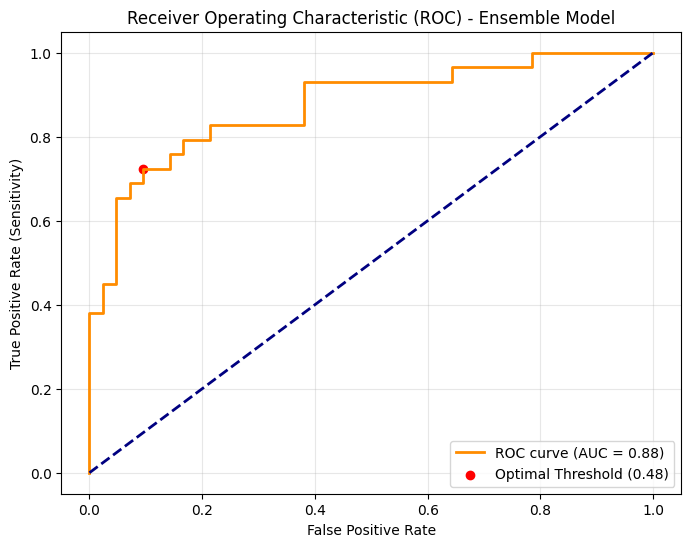

In [3]:
import glob
import torch.nn.functional as F

manifest_path = "/content/drive/MyDrive/Lung_Nodule_Project/processed_patches/manifest.csv"
dataset = LungNoduleDataset(manifest_path)
eval_loader = DataLoader(dataset, batch_size=8, shuffle=False)

# Load all 5 trained models
models = []
for fold in range(1, 6):
    model = HybridGatedFusionModel(num_classes=2).to(device)
    model_path = f"/content/drive/MyDrive/Lung_Nodule_Project/processed_patches/hybrid_model_fold{fold}.pt"
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval() # Set to evaluation mode
    models.append(model)

all_labels = []
all_ensemble_probs = []

print("Running Ensemble Inference across 5 models...")
with torch.no_grad():
    for images, tabs, labels in eval_loader:
        images, tabs = images.to(device), tabs.to(device)

        # Get probabilities from all 5 models
        batch_probs = torch.zeros(images.size(0), 2).to(device)
        for model in models:
            logits = model(images, tabs)
            probs = F.softmax(logits, dim=1)
            batch_probs += probs

        # Average the probabilities
        avg_probs = batch_probs / 5.0

        # Store the probability of the 'Malignant' class (index 1)
        all_ensemble_probs.extend(avg_probs[:, 1].cpu().numpy())
        all_labels.extend(labels.numpy())

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(all_labels, all_ensemble_probs)
roc_auc = auc(fpr, tpr)

# Calculate Youden's J Statistic to find the optimal threshold
# J = Sensitivity (TPR) + Specificity (1 - FPR) - 1
youden_j = tpr - fpr
optimal_idx = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_idx]

print(f"\n--- Evaluation Results ---")
print(f"Ensemble ROC-AUC Score: {roc_auc:.4f}")
print(f"Optimal Probability Threshold (Youden's J): {optimal_threshold:.4f}")

# Generate final predictions using the optimal threshold
final_preds = (np.array(all_ensemble_probs) >= optimal_threshold).astype(int)

print("\nClassification Report (Optimized Threshold):")
print(classification_report(all_labels, final_preds, target_names=['Benign', 'Malignant']))

# Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], marker='o', color='red', label=f'Optimal Threshold ({optimal_threshold:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) - Ensemble Model')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# 4. 3D Grad-CAM Explainability (XAI)

In [4]:
import torch.nn.functional as F
import scipy.ndimage as ndimage
import cv2

class GradCAM3D:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Register hooks to capture the data during the forward/backward passes
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_cam(self, image_tensor, tabular_tensor, target_class=1):
        self.model.eval()
        self.model.zero_grad()

        # Forward pass
        output = self.model(image_tensor, tabular_tensor)

        # Target the specific class (1 = Malignant) for backpropagation
        score = output[0, target_class]
        score.backward()

        # Extract the gradients and activations from our hooks
        gradients = self.gradients[0].cpu().data.numpy()  # Shape: (Channels, D, H, W)
        activations = self.activations[0].cpu().data.numpy()

        # Global Average Pooling on the gradients to get the channel weights
        weights = np.mean(gradients, axis=(1, 2, 3))

        # Weight the feature map activations
        cam = np.zeros(activations.shape[1:], dtype=np.float32)
        for i, w in enumerate(weights):
            cam += w * activations[i]

        # Apply ReLU to only keep features that have a positive influence on the target class
        cam = np.maximum(cam, 0)

        # Upsample the small CAM back to the original image size (64x64x64)
        zoom_factors = (
            image_tensor.shape[2] / cam.shape[0],
            image_tensor.shape[3] / cam.shape[1],
            image_tensor.shape[4] / cam.shape[2]
        )
        cam_upsampled = ndimage.zoom(cam, zoom_factors, order=1)

        # Normalize between [0, 1] for visualization
        cam_upsampled = cam_upsampled - np.min(cam_upsampled)
        cam_upsampled = cam_upsampled / (np.max(cam_upsampled) + 1e-8)

        return cam_upsampled

# Select the first fold model for our XAI demonstration

Visualizing Nodule | True Label: Malignant | Predicted Probability: 0.5058


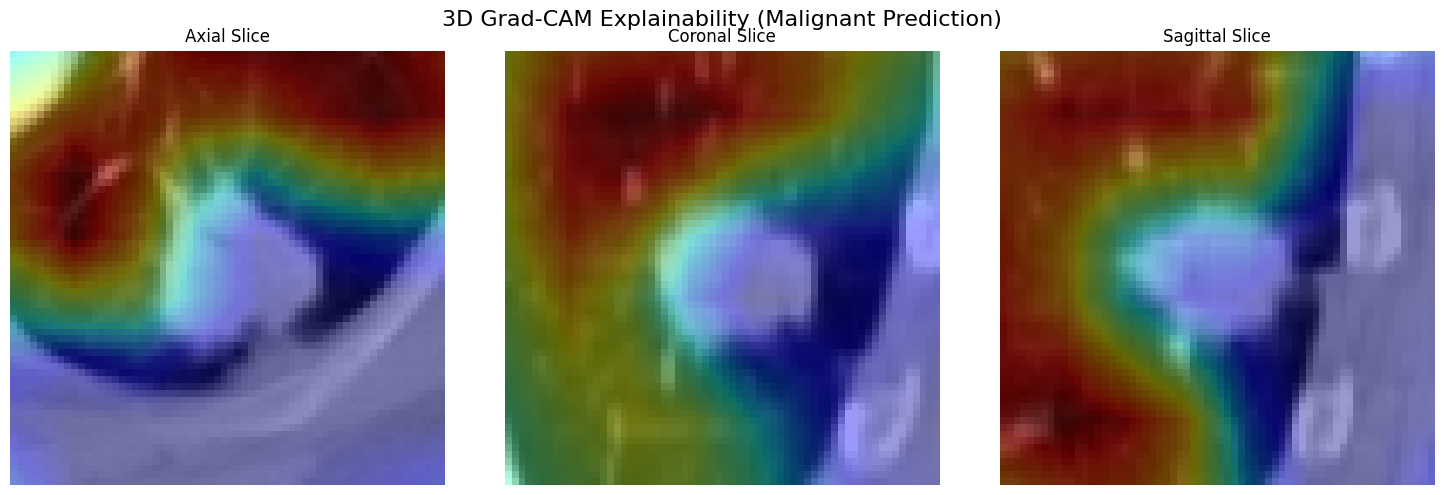

In [5]:
model = models[0]

# We target the absolute last Conv3d layer in your CNN branch
# In your architecture, index 9 is: nn.Conv3d(64, 128, kernel_size=3, padding=1)
target_layer = model.cnn.conv_blocks[9]
grad_cam = GradCAM3D(model, target_layer)

# Find a True Positive sample (Actual Malignant, Predicted Malignant)
sample_img, sample_tab, sample_label = None, None, None
for i in range(len(dataset)):
    img, tab, label = dataset[i]
    if label.item() == 1: # We want to explain a Malignant prediction
        img_batch = img.unsqueeze(0).to(device)
        tab_batch = tab.unsqueeze(0).to(device)

        with torch.no_grad():
            out = model(img_batch, tab_batch)
            prob = F.softmax(out, dim=1)[0, 1].item()

        # If the model correctly flagged it above your optimal threshold, use it!
        if prob >= optimal_threshold:
            sample_img, sample_tab, sample_label = img, tab, label
            break

if sample_img is not None:
    print(f"Visualizing Nodule | True Label: Malignant | Predicted Probability: {prob:.4f}")

    img_batch = sample_img.unsqueeze(0).to(device)
    tab_batch = sample_tab.unsqueeze(0).to(device)

    # We must require gradients on the input image for Grad-CAM to work
    img_batch.requires_grad = True

    # Generate the 3D heatmap
    cam3d = grad_cam.generate_cam(img_batch, tab_batch, target_class=1)

    # Extract the original 3D volume for plotting
    vol = sample_img.squeeze(0).numpy()

    # Find the exact center of the 64x64x64 nodule patch
    mid_z, mid_y, mid_x = vol.shape[0]//2, vol.shape[1]//2, vol.shape[2]//2

    # Plotting the three anatomical planes
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('3D Grad-CAM Explainability (Malignant Prediction)', fontsize=16)

    # Axial View
    axes[0].imshow(vol[mid_z, :, :], cmap='gray')
    axes[0].imshow(cam3d[mid_z, :, :], cmap='jet', alpha=0.4)
    axes[0].set_title('Axial Slice')
    axes[0].axis('off')

    # Coronal View
    axes[1].imshow(vol[:, mid_y, :], cmap='gray')
    axes[1].imshow(cam3d[:, mid_y, :], cmap='jet', alpha=0.4)
    axes[1].set_title('Coronal Slice')
    axes[1].axis('off')

    # Sagittal View
    axes[2].imshow(vol[:, :, mid_x], cmap='gray')
    axes[2].imshow(cam3d[:, :, mid_x], cmap='jet', alpha=0.4)
    axes[2].set_title('Sagittal Slice')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Could not find a true positive malignant nodule in this small batch to visualize.")

# 5. Modality Ablation Study

In [6]:
# We will test our ensemble's performance when one modality is completely "turned off" (zeroed out).
# This proves whether both the 3D images and Tabular features are actually contributing to the high accuracy.

def evaluate_ablation(loader, ensemble_models, ablate_modality=None):
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, tabs, labels in loader:
            images, tabs = images.to(device), tabs.to(device)

            # Ablate (Zero-out) the chosen modality
            if ablate_modality == 'image':
                images = torch.zeros_like(images).to(device)
            elif ablate_modality == 'tabular':
                tabs = torch.zeros_like(tabs).to(device)

            batch_probs = torch.zeros(images.size(0), 2).to(device)
            for model in ensemble_models:
                logits = model(images, tabs)
                probs = F.softmax(logits, dim=1)
                batch_probs += probs

            avg_probs = batch_probs / 5.0
            all_probs.extend(avg_probs[:, 1].cpu().numpy())
            all_labels.extend(labels.numpy())

    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    return auc(fpr, tpr)

print("Running Modality Ablation Study...")
auc_hybrid = roc_auc  # This is the 0.8760 from your previous ensemble run
auc_no_image = evaluate_ablation(eval_loader, models, ablate_modality='image')
auc_no_tab = evaluate_ablation(eval_loader, models, ablate_modality='tabular')

print("\n--- Ablation Study Results (ROC-AUC) ---")
print(f"1. Full Hybrid Model (Images + Tabular) : {auc_hybrid:.4f}")
print(f"2. Tabular MLP Only (Images Zeroed)     : {auc_no_image:.4f}")
print(f"3. 3D CNN Only (Tabular Zeroed)         : {auc_no_tab:.4f}")

# Plotting the Ablation Comparison




Running Modality Ablation Study...

--- Ablation Study Results (ROC-AUC) ---
1. Full Hybrid Model (Images + Tabular) : 0.8760
2. Tabular MLP Only (Images Zeroed)     : 0.8719
3. 3D CNN Only (Tabular Zeroed)         : 0.7315


# Plotting the Ablation Comparison

Text(0.5, 1.0, 'Modality Ablation Study: Impact of Data Sources')

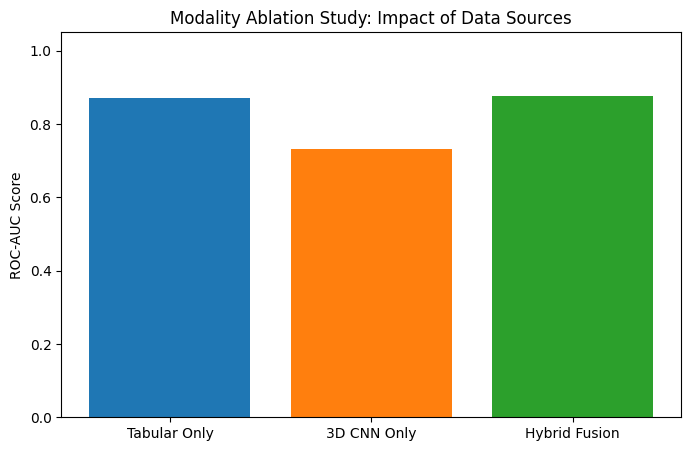

In [7]:
labels = ['Tabular Only', '3D CNN Only', 'Hybrid Fusion']
aucs = [auc_no_image, auc_no_tab, auc_hybrid]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, aucs, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.ylim(0.0, 1.05)
plt.ylabel('ROC-AUC Score')
plt.title('Modality Ablation Study: Impact of Data Sources')


# Add text labels on top of bars

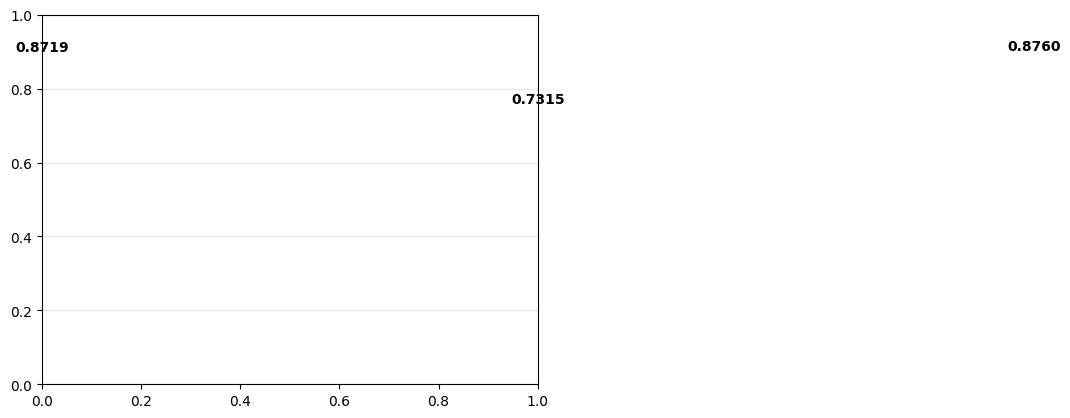

In [8]:
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.show()